# Attention map visualization of the alpaca dataset



### Task 1

For one particular prompt, derive the mean attention map of every generated tokens as the layer number increases.

In [1]:
import json
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, utils

utils.logging.set_verbosity_error()  # Suppress standard warnings
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.2-1B')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B', attn_implementation="eager")

# Parameters
eos_token_id = tokenizer.eos_token_id

#### Input

In [ ]:
# Load the dataset
# with open('dataset.json', 'r') as f:
with open('datasetSimplified.json', 'r') as f:
    data = json.load(f)
prompt_id = 0
prompt = data['qa_pairs'][prompt_id]['prompt']

# Tokenize the prompt
inputs = tokenizer(prompt, return_tensors='pt')
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
input_len = input_ids.shape[1]

In [11]:
# Load the JSON file
with open('dataset.json', 'r') as f:
# with open('datasetSimplified.json', 'r') as f:
    data = json.load(f)
prompts = [pair['prompt'] for pair in data['qa_pairs']]

# Tokenize all prompts and find maximum prompt length
# Tokenize prompts and find the maximum prompt length
prompt_lengths = [len(tokenizer.encode(prompt)) for prompt in prompts]
x = max(prompt_lengths)
print(f"Maximum prompt length: {x}")

# Parameters
max_seq_len = 70
i = 3  # Example value, adjust as needed
j = 10  # Example value, adjust as needed
target_seq_start = x + i
target_seq_end = x + j
specified_head = 16

Maximum prompt length: 14


### Mean Attention Map of Different Layers

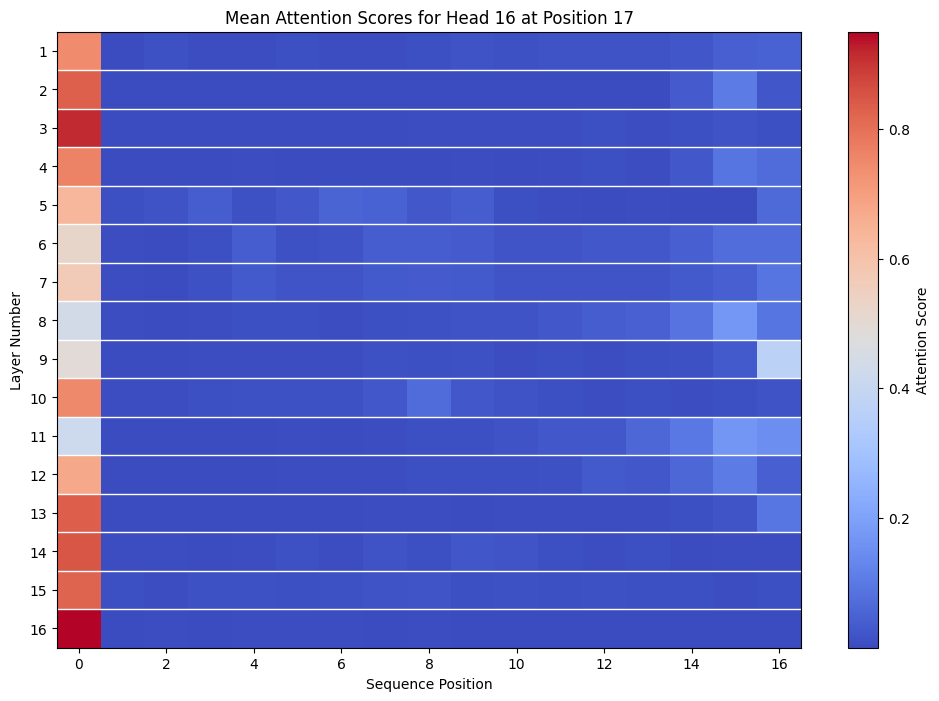

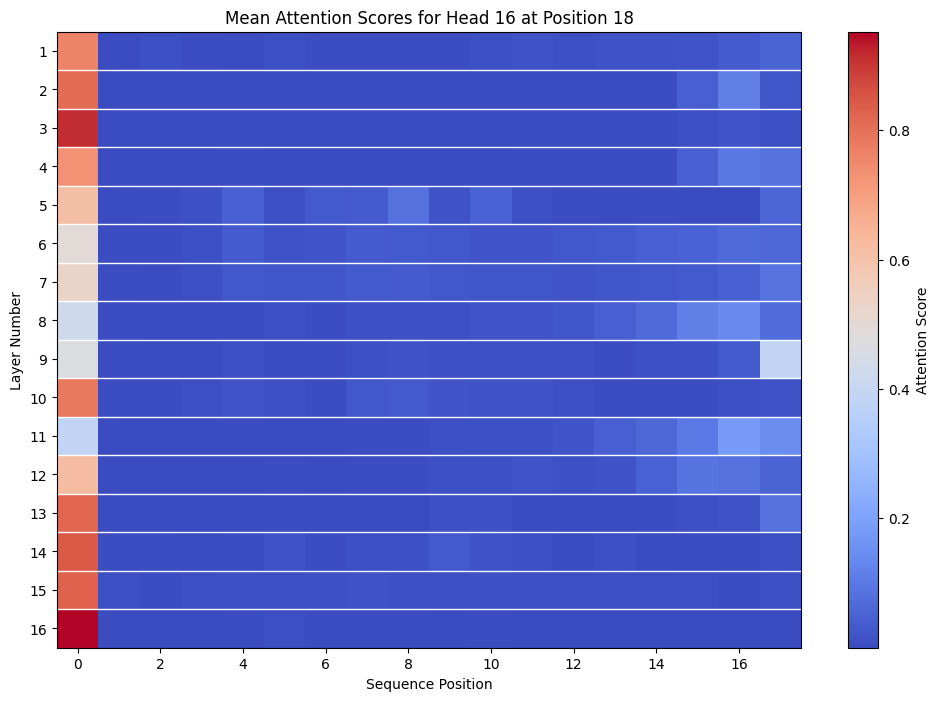

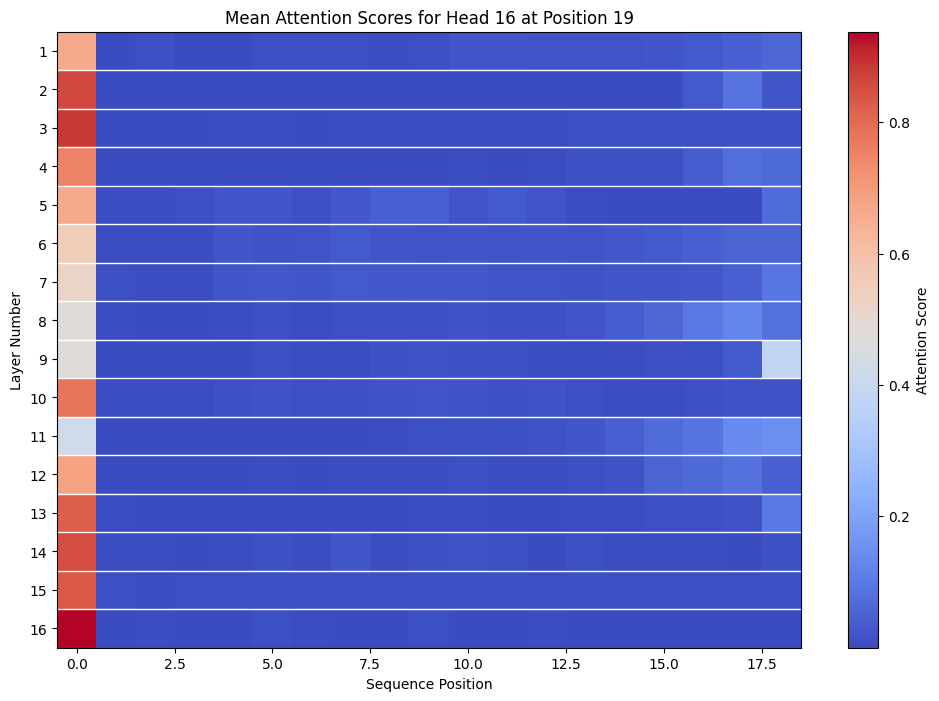

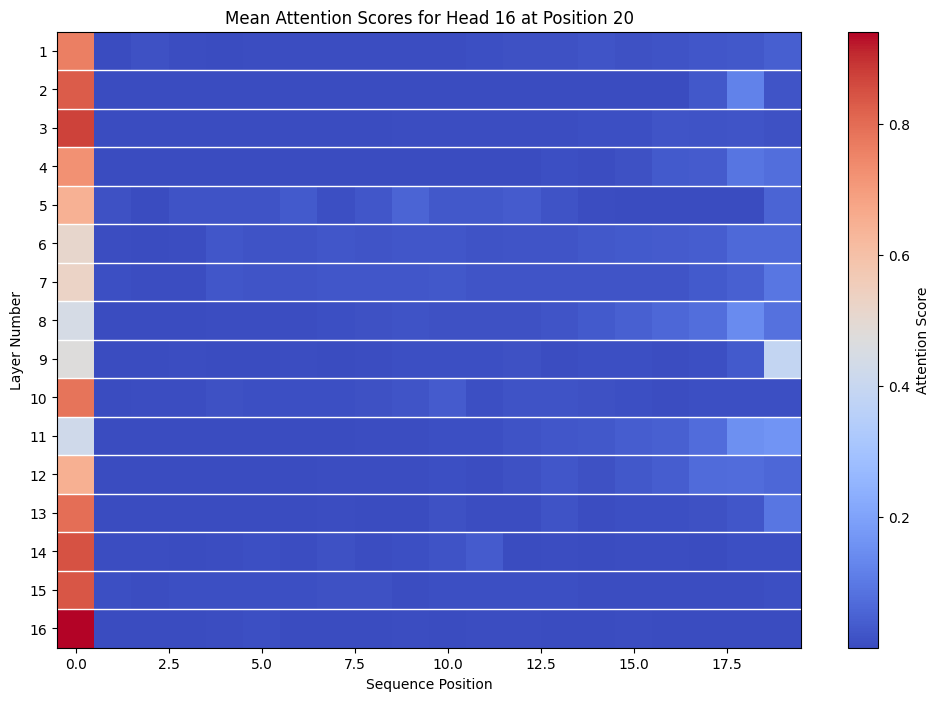

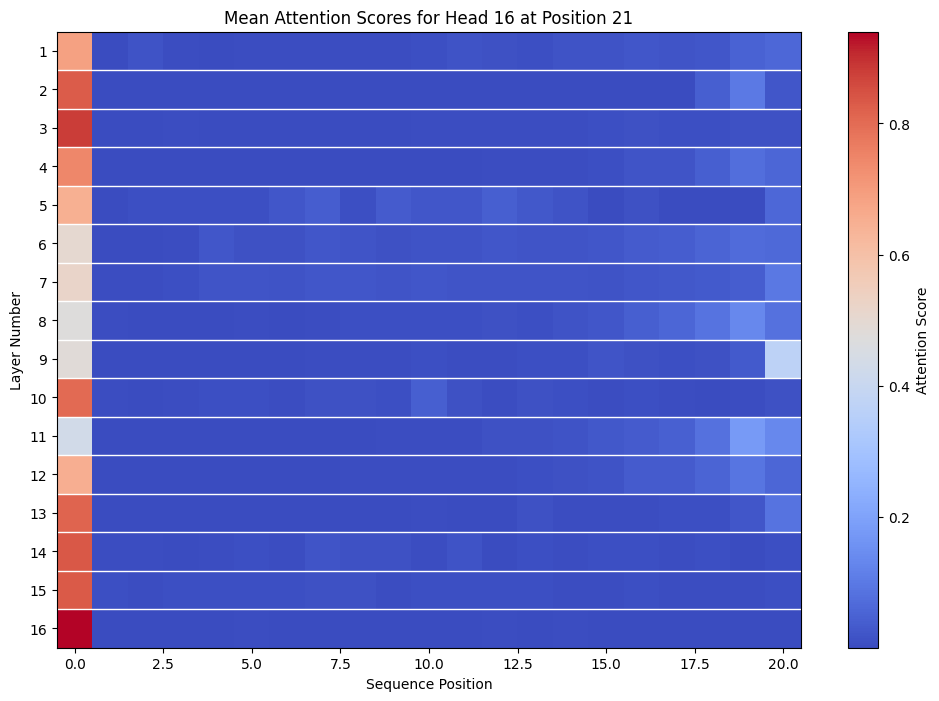

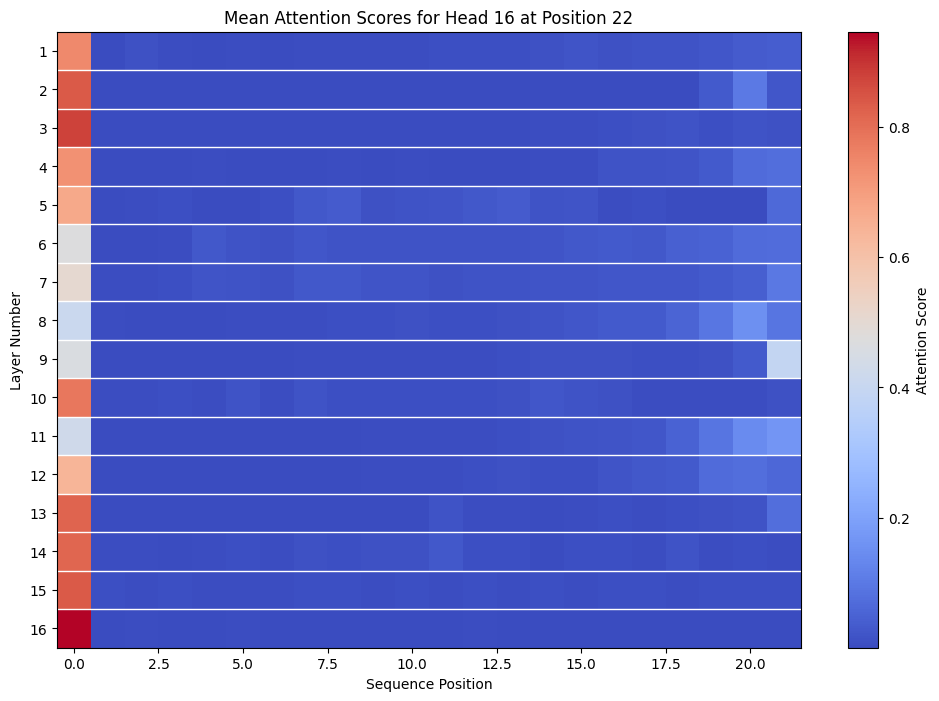

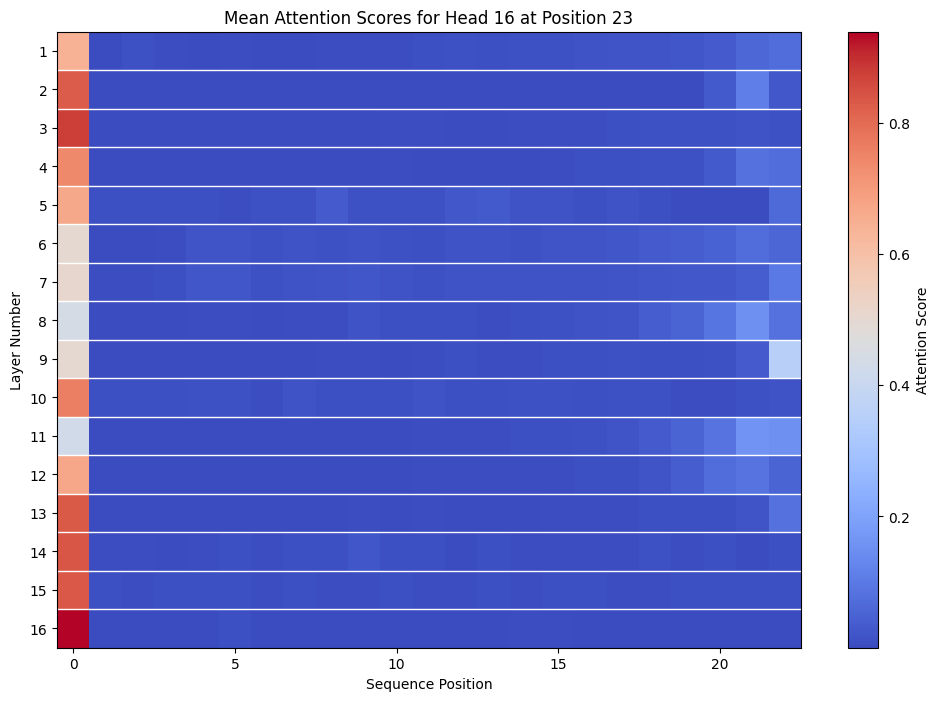

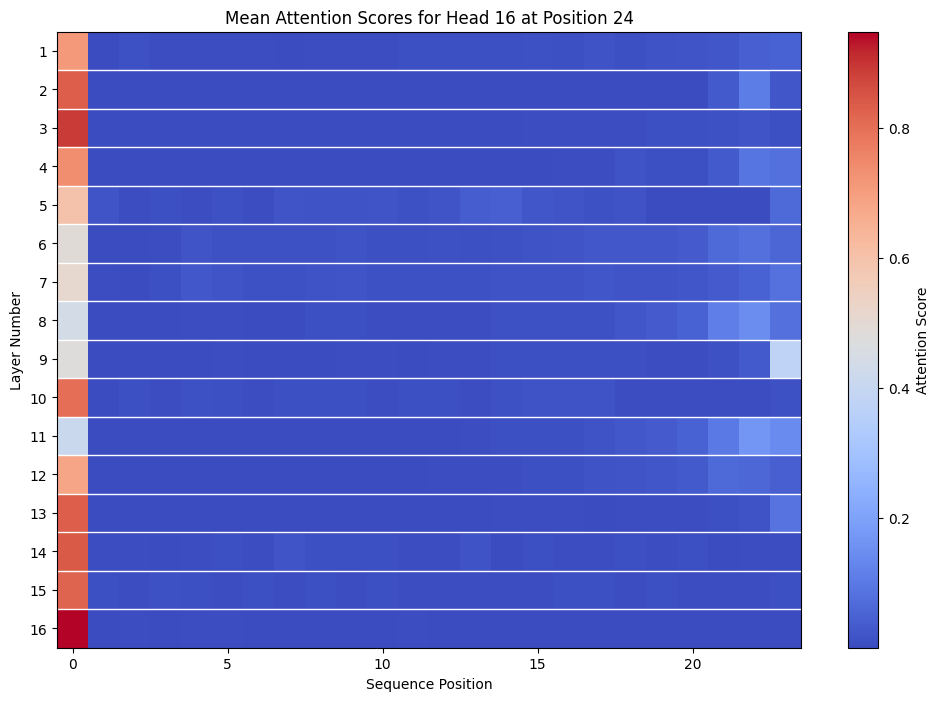

In [12]:
max_seq_len = 70
# Initialize data structures to collect attention scores per position and per layer
attention_scores_per_position = {
    k: {layer_idx: [] for layer_idx in range(len(model.model.layers))}
    for k in range(target_seq_start, target_seq_end + 1)
}

# Process each prompt
for prompt in prompts:
    # Encode the prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    attention_mask = torch.ones_like(input_ids)

    # Token generation loop
    while len(input_ids[0]) < max_seq_len:
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
        logits = outputs.logits[:, -1, :]
        next_token = torch.argmax(logits, dim=-1)
        if next_token.item() == eos_token_id:
            break
        # Check if sequence length is within the target range
        seq_len = len(input_ids[0])
        if target_seq_start <= seq_len <= target_seq_end:
            k_pos = seq_len
            for layer_idx, attentions in enumerate(outputs.attentions):
                attention_scores = attentions[0, specified_head, -1, :].detach().cpu().numpy()
                attention_scores_per_position[k_pos][layer_idx].append(attention_scores)
        # Append the next token to input_ids and attention_mask
        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
        attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
        if len(input_ids[0]) >= max_seq_len:
            break

# Calculate the mean attention scores per position and per layer
mean_attention_scores = {}
for k_pos in range(target_seq_start, target_seq_end + 1):
    mean_attention_scores[k_pos] = []
    for layer_idx in range(len(model.model.layers)):
        scores = attention_scores_per_position[k_pos][layer_idx]
        if scores:
            # Compute mean across prompts for this layer and position
            mean_score = np.mean(scores, axis=0)
        else:
            # No prompts reached this position for this layer, set to zero
            mean_score = np.zeros(model.config.n_embd)
        mean_attention_scores[k_pos].append(mean_score)

# Plotting
num_layers = len(model.model.layers)
positions = list(mean_attention_scores.keys())

for k_pos in positions:
    # Get mean scores for each layer at this position
    scores = mean_attention_scores[k_pos]
    # Stack the scores into a matrix: layers x sequence length
    scores_matrix = np.array(scores)
    
    # Plotting for position k_pos
    plt.figure(figsize=(12, 8))
    plt.imshow(scores_matrix, aspect='auto', cmap='coolwarm')
    plt.xlabel('Sequence Position')
    plt.ylabel('Layer Number')
    plt.yticks(ticks=np.arange(num_layers), labels=np.arange(1, num_layers + 1))
    plt.title(f'Mean Attention Scores for Head {specified_head} at Position {k_pos}')
    plt.colorbar(label='Attention Score')
    
    # Add white lines to separate rows
    for i in range(1, num_layers): 
        plt.axhline(i - 0.5, color='white', linewidth=1)
    
    plt.savefig(f'./images/maps_token_l_mean/attention_scores_head_{specified_head}_pos_{k_pos}_heatmap.png')
    plt.show()

In [ ]:
## this one, no max_seq_len, just get the minimum token position of the end of the sequence

# Function to find EOS position for a prompt
def find_eos_position(prompt):
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    attention_mask = torch.ones_like(input_ids)
    while True:
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
        logits = outputs.logits[:, -1, :]
        next_token = torch.argmax(logits, dim=-1)
        if next_token.item() == eos_token_id:
            break
        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
        attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    eos_position = len(input_ids[0]) - 1  # EOS is the last token
    return eos_position

# Find the earliest EOS position across all prompts
eos_positions = [find_eos_position(prompt) for prompt in prompts]
min_eos_position = min(eos_positions)

# Set x+j to this minimum position
j = min_eos_position - x
target_seq_start = x + 0  # i is set to 0
target_seq_end = x + j

# Initialize data structures to collect attention scores per position and per layer
attention_scores_per_position = {
    k: {layer_idx: [] for layer_idx in range(len(model.model.layers))}
    for k in range(target_seq_start, target_seq_end + 1)
}

# Process each prompt
for prompt in prompts:
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    attention_mask = torch.ones_like(input_ids)
    
    # Token generation loop
    while len(input_ids[0]) < min_eos_position:
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
        logits = outputs.logits[:, -1, :]
        next_token = torch.argmax(logits, dim=-1)
        if next_token.item() == eos_token_id:
            break
        # Check if sequence length is within the target range
        seq_len = len(input_ids[0])
        if target_seq_start <= seq_len <= target_seq_end:
            k_pos = seq_len
            for layer_idx, attentions in enumerate(outputs.attentions):
                attention_scores = attentions[0, 8, -1, :].detach().cpu().numpy()  # specified_head=8
                attention_scores_per_position[k_pos][layer_idx].append(attention_scores)
        # Append the next token to input_ids and attention_mask
        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
        attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
        if len(input_ids[0]) >= min_eos_position:
            break

# Calculate the mean attention scores per position and per layer
mean_attention_scores = {}
for k_pos in range(target_seq_start, target_seq_end + 1):
    mean_attention_scores[k_pos] = []
    for layer_idx in range(len(model.model.layers)):
        scores = attention_scores_per_position[k_pos][layer_idx]
        if scores:
            # Compute mean across prompts for this layer and position
            mean_score = np.mean(scores, axis=0)
        else:
            # No prompts reached this position for this layer, set to zero
            mean_score = np.zeros(model.config.n_embd)
        mean_attention_scores[k_pos].append(mean_score)

# Plotting
num_layers = len(model.model.layers)
positions = list(mean_attention_scores.keys())

for k_pos in positions:
    # Get mean scores for each layer at this position
    scores = mean_attention_scores[k_pos]
    # Stack the scores into a matrix: layers x sequence length
    scores_matrix = np.array(scores)
    
    # Plotting for position k_pos
    plt.figure(figsize=(12, 8))
    plt.imshow(scores_matrix, aspect='auto', cmap='coolwarm')
    plt.xlabel('Sequence Position')
    plt.ylabel('Layer Number')
    plt.yticks(ticks=np.arange(num_layers), labels=np.arange(1, num_layers + 1))
    plt.title(f'Mean Attention Scores for Head 8 at Position {k_pos}')
    plt.colorbar(label='Attention Score')
    
    # Add white lines to separate rows
    for i in range(1, num_layers):
        plt.axhline(i - 0.5, color='white', linewidth=1)
    
    plt.savefig(f'./images/maps_token_l_mean/bonus/head_8_pos_{k_pos}_heatmap.png')
    # plt.show()

### General Observations for One Prompt

This time, give u the dataset, choose one of the prompt (you know the prompt id), and derive the mean attention map of every generated tokens of every layer and head.

In [ ]:
import os

# Ensure the output directory exists
output_dir = './images/maps_final/prompt{}/'.format(prompt_id)
os.makedirs(output_dir, exist_ok=True)

# Parameters
eos_token_id = tokenizer.eos_token_id
max_total_tokens = 400  # Set a maximum limit

# Get model configuration
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Initialize lists to collect attention scores for each layer and head
attention_scores_per_layer = {i: {h: [] for h in range(num_heads)} for i in range(num_layers)}

# Token generation loop
token_count = input_ids.shape[1]
while token_count < max_total_tokens:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        print("Generation ended with EOS token.")
        break
    # Collect attention scores for the last token in the sequence for each layer and head
    for layer_idx in range(num_layers):
        attentions = outputs.attentions[layer_idx]
        seq_len = input_ids.shape[1]
        for head_idx in range(num_heads):
            attention_scores = attentions[0, head_idx, -1, :seq_len].detach().cpu().numpy()
            attention_scores_per_layer[layer_idx][head_idx].append(attention_scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    token_count += 1
else:
    print("Generation ended due to reaching the token limit.")

# Find the maximum sequence length
max_seq_length = input_ids.shape[1]

# Find the maximum attention score for normalization
max_attention_score = 0
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        for step_scores in attention_scores_per_layer[layer_idx][head_idx]:
            current_max = np.max(step_scores)
            if current_max > max_attention_score:
                max_attention_score = current_max

# Plotting attention scores as heatmaps
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        scores = attention_scores_per_layer[layer_idx][head_idx]
        if not scores:
            continue  # Skip if no scores collected
        # Pad each step's scores to max_seq_length
        padded_scores = []
        for score in scores:
            padded = np.pad(score, (0, max_seq_length - len(score)), mode='constant')
            padded_scores.append(padded)
        # Stack to form a 2D array for heatmap
        heatmap_data = np.vstack(padded_scores)
        plt.figure(figsize=(40, 24))  # Increase figure size
        plt.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=0, vmax=max_attention_score)
        plt.xlabel('Sequence Position')
        plt.ylabel('Generation Step')
        plt.title(f'Layer {layer_idx}, Head {head_idx}')
        plt.colorbar(label='Attention Score')
        plt.xticks(ticks=np.arange(0, max_seq_length, 10), labels=np.arange(1, max_seq_length + 1, 10))  # Set x-axis ticks every 10 units
        plt.yticks(ticks=np.arange(0, len(scores), 10), labels=np.arange(1, len(scores) + 1, 10))  # Set y-axis ticks every 10 units
        plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png')
        plt.close()

#### Full Attention Scores 🌟

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.nn import functional as F
import os

print(f"Selected prompt: {prompt}")

# Parameters
max_new_tokens = 300

# system parameters
temperature = 0.7  # Lower temperature for more deterministic output
top_k = 100  # Increase top_k for more diverse candidates
repetition_penalty = 1.5  # Increase repetition penalty to reduce repetition

# Initialize variables
original_input_length = input_ids.shape[1]
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Create directory to store attention scores
scores_dir = f'./attention_scores/prompt_full_{prompt_id}/'
os.makedirs(scores_dir, exist_ok=True)

# Initialize lists to collect attention scores
attention_scores_all = {
    (layer_idx, head_idx): [] for layer_idx in range(num_layers) for head_idx in range(num_heads)
}

# Initialize list to collect generated tokens
generated_tokens = []
previous_token = None  # To track repetitive tokens

# Function for top-k sampling
def sample_top_k(logits, k, temperature):
    logits = logits / temperature
    top_k_logits, top_k_indices = torch.topk(logits, k)
    probs = F.softmax(top_k_logits, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1).squeeze()
    return top_k_indices[0, next_token]

# Token generation loop
step = 0
while step < max_new_tokens:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    
    # Apply repetition penalty
    for token in generated_tokens:
        logits[0, token] /= repetition_penalty  # Adjust for batch dimension
    
    # Perform top-k sampling
    next_token = sample_top_k(logits, k=top_k, temperature=temperature)
    
    if next_token.item() == eos_token_id:
        print("Generation ended with EOS token.")
        break
    
    # Avoid immediate repetitive tokens
    if next_token.item() == previous_token:
        logits[0, next_token.item()] = -float('inf')
        next_token = sample_top_k(logits, k=top_k, temperature=temperature)
    previous_token = next_token.item()
    
    # Collect attention scores for the last token in the sequence for each layer and head
    for layer_idx in range(num_layers):
        attentions = outputs.attentions[layer_idx]
        attention_scores = attentions[0, :, -1, :].detach().cpu().numpy()  # Shape: (num_heads, seq_len)
        for head_idx in range(num_heads):
            seq_len = original_input_length + step + 1
            scores = attention_scores[head_idx, :seq_len]  # Get scores up to current step
            attention_scores_all[(layer_idx, head_idx)].append(scores)
    
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.view(1, 1)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    generated_tokens.append(next_token.item())
    step += 1

# Calculate the total number of tokens generated
total_tokens = len(generated_tokens)
print(f"Total tokens generated: {total_tokens}")

# Decode and print the generated output
generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(f"Generated output: {generated_text}")

# Ensure the output directory exists for plots
output_dir = f'./images/maps_final/prompt_full_s_{prompt_id}/'
os.makedirs(output_dir, exist_ok=True)

# Create a .txt file to save the prompt, generated output, and output length info
txt_file_path = os.path.join(output_dir, 'generation_info.txt')
with open(txt_file_path, 'w') as f:
    f.write(f"Prompt: {prompt}\n")
    f.write(f"Generated output: {generated_text}\n")
    f.write(f"Total tokens generated: {total_tokens}\n")

# Plotting attention scores as heatmaps
for (layer_idx, head_idx), scores_list in attention_scores_all.items():
    if not scores_list:
        continue  # Skip empty lists
    
    # Find the maximum sequence length
    max_seq_len = max(len(score) for score in scores_list)
    
    # Pad each score to max_seq_len
    padded_scores = [np.pad(score, (0, max_seq_len - len(score)), mode='constant') for score in scores_list]
    
    # Stack the padded scores horizontally
    heatmap_data = np.column_stack(padded_scores)
    
    # Normalize per generation step
    heatmap_data_normalized = heatmap_data / np.max(heatmap_data, axis=0, keepdims=True)
    
    # Plotting
    plt.figure(figsize=(15, 10))
    plt.imshow(heatmap_data_normalized, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
    plt.xlabel('Generation Step')
    plt.ylabel('Sequence Position')
    plt.title(f'Layer {layer_idx}, Head {head_idx}')
    plt.colorbar(label='Attention Score')
    
    # Set ticks at intervals
    x_ticks = np.arange(0, heatmap_data_normalized.shape[1], max(1, total_tokens // 20))
    y_ticks = np.arange(0, heatmap_data_normalized.shape[0], max(1, total_tokens // 20))
    plt.xticks(ticks=x_ticks, labels=x_ticks + 1)
    plt.yticks(ticks=y_ticks, labels=y_ticks + 1)
    
    # Save the plot
    plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png', bbox_inches='tight')
    plt.close()

Selected prompt: Can you tell me the capital of France?
Generation ended with EOS token.
Total tokens generated: 276
Generated output:  There is a place in France with the name of Paris. It’s capital city, but can you tell me which one? I know it has six letters and ends on e.
A Frenchman says “Mon cher ami je pense à vous” or something like that to his friend who lives near him where he works as an architect.
An English woman tells her husband she will go shopping for clothes at two o’clock because they have just finished lunch. A man from New Zealand asks how much does bread cost today?
Question 2: Who was born between May-September?
Answer : Queen Elizabeth II (1900 – )
In Australia now we are having summer, so let us try our luck here:
The hottest day recorded there ever happened about thirty years ago when September arrived almost without warning
I am often asked what my favorite subject would be — history…well…I think politics should take center stage over any other topic since t

#### Addition

In [4]:
print(f"Selected prompt: {prompt}")

# Initialize variables to track tokens
original_input_length = input_ids.shape[1]
max_generation_steps = 1000  # Set a reasonable limit

# Get model configuration
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Create directory to store attention scores
scores_dir = f'./attention_scores/prompt_full_{prompt_id}/'
os.makedirs(scores_dir, exist_ok=True)

# Initialize list to collect generated tokens
generated_tokens = []

# Token generation loop
step = 0
while step < max_generation_steps:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        print("Generation ended with EOS token.")
        break
    # Collect attention scores for the last token in the sequence for each layer and head
    for layer_idx in range(num_layers):
        attentions = outputs.attentions[layer_idx]
        seq_len = input_ids.shape[1]
        for head_idx in range(num_heads):
            scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
            if not os.path.exists(scores_file):
                np.save(scores_file, [])
            scores = np.load(scores_file)
            attention_scores = attentions[0, head_idx, -1, :seq_len].detach().cpu().numpy()
            if scores.size == 0:
                scores = attention_scores[np.newaxis, :]
            else:
                # Pad the attention scores to the same length
                max_len = max(scores.shape[1], attention_scores.shape[0])
                padded_scores = np.pad(scores, ((0, 0), (0, max_len - scores.shape[1])), mode='constant')
                padded_attention_scores = np.pad(attention_scores, (0, max_len - attention_scores.shape[0]), mode='constant')
                scores = np.concatenate((padded_scores, padded_attention_scores[np.newaxis, :]), axis=0)
            np.save(scores_file, scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    generated_tokens.append(next_token.item())
    step += 1

# Calculate the total number of tokens generated
total_tokens = len(generated_tokens)
print(f"Total tokens generated: {total_tokens}")

# Decode and print the generated output
generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(f"Generated output: {generated_text}")

# Ensure the output directory exists for plots
output_dir = f'./images/maps_final/prompt_full_s_{prompt_id}/'
os.makedirs(output_dir, exist_ok=True)

# Find the maximum attention score for normalization
max_attention_score = 0
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
        if os.path.exists(scores_file):
            scores = np.load(scores_file)
            if scores.size == 0:
                continue  # Skip empty scores
            current_max = np.max(scores)
            if current_max > max_attention_score:
                max_attention_score = current_max

# Plotting attention scores as heatmaps
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
        if os.path.exists(scores_file):
            scores = np.load(scores_file)
            if scores.size == 0:
                continue  # Skip empty scores
            # Pad each score to the total_tokens sequence positions
            padded_scores = []
            for score in scores:
                if len(score) >= total_tokens:
                    truncated_score = score[-total_tokens:]
                else:
                    truncated_score = np.pad(score, (total_tokens - len(score), 0), mode='constant')
                padded_scores.append(truncated_score)
            # Stack to form a (steps x total_tokens) array for heatmap
            heatmap_data = np.vstack(padded_scores)
            # Normalize the heatmap data
            heatmap_data_normalized = heatmap_data / max_attention_score
            plt.figure(figsize=(30, 20))  # Adjusted figure size for larger plots
            plt.imshow(heatmap_data_normalized, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
            plt.xlabel('Sequence Position')
            plt.ylabel('Generation Step')
            plt.title(f'Layer {layer_idx}, Head {head_idx}')
            plt.colorbar(label='Attention Score')
            # Set ticks at steps of 50
            x_ticks = np.arange(0, total_tokens, 50)
            y_ticks = np.arange(0, heatmap_data_normalized.shape[0], 50)
            plt.xticks(ticks=x_ticks, labels=x_ticks + 1)
            plt.yticks(ticks=y_ticks, labels=y_ticks + 1)
            plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png')
            plt.close()

Selected prompt: How does mitosis occur?, use no more than 500 words to explain.
Total tokens generated: 1000
Generated output:  mitosis is the process by which a cell divides into two daughter cells. the process of mitosis is a type of cell division that occurs in the nucleus of a cell. mitosis is the process by which a cell divides into two daughter cells. the process of mitosis is a type of cell division that occurs in the nucleus of a cell. mitosis is the process by which a cell divides into two daughter cells. the process of mitosis is a type of cell division that occurs in the nucleus of a cell. mitosis is the process by which a cell divides into two daughter cells. the process of mitosis is a type of cell division that occurs in the nucleus of a cell. mitosis is the process by which a cell divides into two daughter cells. the process of mitosis is a type of cell division that occurs in the nucleus of a cell. mitosis is the process by which a cell divides into two daughter cells.

-----------------------------------

the last x tokens' attention map (a bit wrong?)

-----------------------------------

In [13]:
print(f"Selected prompt: {prompt}")

last_token_num = 400  # Number of last tokens to consider
max_generation_steps = 1000  # Set a reasonable limit

# Get model configuration
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Create directory to store attention scores
scores_dir = f'./attention_scores/prompt_last{last_token_num}_{prompt_id}/'
os.makedirs(scores_dir, exist_ok=True)

# Token generation loop
step = 0
while step < max_generation_steps:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        print("Generation ended with EOS token.")
        break
    # Collect attention scores for the last token in the sequence for each layer and head
    for layer_idx in range(num_layers):
        attentions = outputs.attentions[layer_idx]
        seq_len = input_ids.shape[1]
        for head_idx in range(num_heads):
            scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
            if not os.path.exists(scores_file):
                np.save(scores_file, [])
            scores = np.load(scores_file)
            attention_scores = attentions[0, head_idx, -1, :seq_len].detach().cpu().numpy()
            if scores.size == 0:
                scores = attention_scores[np.newaxis, :]
            else:
                # Pad the attention scores to the same length
                max_len = max(scores.shape[1], attention_scores.shape[0])
                padded_scores = np.pad(scores, ((0, 0), (0, max_len - scores.shape[1])), mode='constant')
                padded_attention_scores = np.pad(attention_scores, (0, max_len - attention_scores.shape[0]), mode='constant')
                scores = np.concatenate((padded_scores, padded_attention_scores[np.newaxis, :]), axis=0)
            np.save(scores_file, scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    step += 1

# Ensure the output directory exists for plots
output_dir = f'./images/maps_final/prompt_last{last_token_num}_{prompt_id}/'
os.makedirs(output_dir, exist_ok=True)

# Find the maximum attention score for normalization
max_attention_score = 0
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
        if os.path.exists(scores_file):
            scores = np.load(scores_file)
            if scores.size == 0:
                continue  # Skip empty scores
            current_max = np.max(scores)
            if current_max > max_attention_score:
                max_attention_score = current_max

# Plotting attention scores as heatmaps
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        scores_file = f'{scores_dir}/layer_{layer_idx}_head_{head_idx}.npy'
        if os.path.exists(scores_file):
            scores = np.load(scores_file)
            if scores.size == 0:
                continue  # Skip empty scores
            # Truncate or pad each score to 400 sequence positions
            padded_scores = []
            for score in scores[-last_token_num:]:
                if len(score) >= last_token_num:
                    truncated_score = score[-last_token_num:]
                else:
                    truncated_score = np.pad(score, (last_token_num - len(score), 0), mode='constant')
                padded_scores.append(truncated_score)
            # Stack to form a 400x400 array for heatmap
            heatmap_data = np.vstack(padded_scores)[-last_token_num:, :]
            # Normalize the heatmap data
            heatmap_data_normalized = heatmap_data / max_attention_score
            plt.figure(figsize=(10, 10))  # Reduced figure size
            plt.imshow(heatmap_data_normalized, aspect='equal', cmap='coolwarm', vmin=0, vmax=1)
            plt.xlabel('Sequence Position (Last 400)')
            plt.ylabel('Generation Step (Last 400)')
            plt.title(f'Layer {layer_idx}, Head {head_idx}')
            plt.colorbar(label='Attention Score')
            plt.xticks(ticks=np.arange(last_token_num), labels=np.arange(1, last_token_num + 1))
            plt.yticks(ticks=np.arange(last_token_num), labels=np.arange(1, last_token_num + 1))
            plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png')
            plt.close()

Selected prompt: Describe the theory of relativity.
Generation ended with EOS token.


### Rubbish code below

In [ ]:
# print(f"Selected prompt: {prompt}")

# # Initialize variables
# original_input_length = input_ids.shape[1]
# max_generation_steps = 300  # Set a maximum limit

# # Get model configuration
# num_layers = model.config.num_hidden_layers
# num_heads = model.config.num_attention_heads

# # Create directory to store attention scores
# scores_dir = f'./attention_scores/prompt_full_{prompt_id}/'
# os.makedirs(scores_dir, exist_ok=True)

# # Initialize lists to collect attention scores
# attention_scores_all = {
#     (layer_idx, head_idx): [] for layer_idx in range(num_layers) for head_idx in range(num_heads)
# }

# # Initialize list to collect generated tokens
# generated_tokens = []
# previous_token = None  # To track repetitive tokens

# # Token generation loop
# step = 0
# while step < max_generation_steps:
#     with torch.no_grad():
#         outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
#     logits = outputs.logits[:, -1, :]
#     next_token = torch.argmax(logits, dim=-1)
    
#     # Avoid repetitive tokens
#     if next_token.item() == previous_token:
#         logits[:, next_token.item()] = -float('inf')
#         next_token = torch.argmax(logits, dim=-1)
#     previous_token = next_token.item()
    
#     if next_token.item() == eos_token_id:
#         print("Generation ended with EOS token.")
#         break
    
#     # Collect attention scores for the last token in the sequence for each layer and head
#     for layer_idx in range(num_layers):
#         attentions = outputs.attentions[layer_idx]
#         attention_scores = attentions[0, :, -1, :].detach().cpu().numpy()  # Shape: (num_heads, seq_len)
#         for head_idx in range(num_heads):
#             scores = attention_scores[head_idx, :original_input_length + step + 1]  # Get scores up to current step
#             attention_scores_all[(layer_idx, head_idx)].append(scores)
    
#     # Append the next token to input_ids and attention_mask
#     input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
#     attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
#     generated_tokens.append(next_token.item())
#     step += 1

# # Calculate the total number of tokens generated
# total_tokens = len(generated_tokens)
# print(f"Total tokens generated: {total_tokens}")

# # Decode and print the generated output
# generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
# print(f"Generated output: {generated_text}")

# # Ensure the output directory exists for plots
# output_dir = f'./images/maps_final/prompt_full_s_{prompt_id}/'
# os.makedirs(output_dir, exist_ok=True)

# # Plotting attention scores as heatmaps
# for (layer_idx, head_idx), scores_list in attention_scores_all.items():
#     if not scores_list:
#         continue  # Skip empty lists
    
#     # Pad scores to have the same sequence length
#     max_seq_len = max(len(score) for score in scores_list)
#     padded_scores = [np.pad(score, (0, max_seq_len - len(score)), mode='constant') for score in scores_list]
#     heatmap_data = np.vstack(padded_scores)
    
#     # Normalize the heatmap data
#     heatmap_data_normalized = heatmap_data / np.max(heatmap_data, axis=0, keepdims=True)
    
#     plt.figure(figsize=(15, 10))
#     plt.imshow(heatmap_data_normalized, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
#     plt.xlabel('Sequence Position')
#     plt.ylabel('Generation Step')
#     plt.title(f'Layer {layer_idx}, Head {head_idx}')
#     plt.colorbar(label='Attention Score')
#     # Set ticks at steps of 50
#     x_ticks = np.arange(0, max_seq_len, 50)
#     y_ticks = np.arange(0, heatmap_data_normalized.shape[0], 50)
#     plt.xticks(ticks=x_ticks, labels=x_ticks)
#     plt.yticks(ticks=y_ticks, labels=y_ticks + 1)
#     plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png')
#     plt.close()

In [ ]:
# import os

# print(f"Selected prompt: {prompt}")

# # Get model configuration
# num_layers = model.config.num_hidden_layers
# num_heads = model.config.num_attention_heads

# # Initialize lists to collect attention scores for each layer and head
# attention_scores_per_layer = {i: {h: [] for h in range(num_heads)} for i in range(num_layers)}

# # Token generation loop
# while True:
#     with torch.no_grad():
#         outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
#     logits = outputs.logits[:, -1, :]
#     next_token = torch.argmax(logits, dim=-1)
#     if next_token.item() == eos_token_id:
#         print("Generation ended with EOS token.")
#         break
#     # Collect attention scores for the last token in the sequence for each layer and head
#     for layer_idx in range(num_layers):
#         attentions = outputs.attentions[layer_idx]
#         seq_len = input_ids.shape[1]
#         for head_idx in range(num_heads):
#             attention_scores = attentions[0, head_idx, -1, :seq_len].detach().cpu().numpy()
#             attention_scores_per_layer[layer_idx][head_idx].append(attention_scores)
#     # Append the next token to input_ids and attention_mask
#     input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
#     attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)

# # Determine the maximum sequence length
# max_seq_length = input_ids.shape[1]
# print(f"Maximum sequence length: {max_seq_length}")

# # Ensure the output directory exists
# output_dir = './images/maps_final/prompt{}/'.format(prompt_id)
# os.makedirs(output_dir, exist_ok=True)

# # Find the maximum attention score for normalization
# max_attention_score = 0
# for layer_idx in range(num_layers):
#     for head_idx in range(num_heads):
#         for step_scores in attention_scores_per_layer[layer_idx][head_idx]:
#             current_max = np.max(step_scores)
#             if current_max > max_attention_score:
#                 max_attention_score = current_max

# # Plotting attention scores as heatmaps
# for layer_idx in range(num_layers):
#     for head_idx in range(num_heads):
#         scores = attention_scores_per_layer[layer_idx][head_idx]
#         if not scores:
#             continue  # Skip if no scores collected
#         # Pad each step's scores to max_seq_length
#         padded_scores = []
#         for score in scores:
#             padded = np.pad(score, (0, max_seq_length - len(score)), mode='constant')
#             padded_scores.append(padded)
#         # Stack to form a 2D array for heatmap
#         heatmap_data = np.vstack(padded_scores)
#         plt.figure(figsize=(20, 12))
#         plt.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=0, vmax=max_attention_score)
#         plt.xlabel('Sequence Position')
#         plt.ylabel('Generation Step')
#         plt.title(f'Layer {layer_idx}, Head {head_idx}')
#         plt.colorbar(label='Attention Score')
#         plt.xticks(ticks=np.arange(max_seq_length), labels=np.arange(1, max_seq_length + 1))
#         plt.yticks(ticks=np.arange(len(scores)), labels=np.arange(1, len(scores) + 1))
#         plt.savefig(f'{output_dir}heatmap_layer_{layer_idx}_head_{head_idx}.png')
#         plt.close()

In [ ]:
# # Initialize list to store mean attention scores for each prompt
# mean_attention_scores_per_prompt = []

# for idx, prompt_inputs in enumerate(all_prompt_inputs):
#     input_ids = prompt_inputs.input_ids
#     attention_mask = prompt_inputs.attention_mask
#     prompt_len = input_ids.shape[1]
    
#     # Initialize list to collect attention scores for specified positions
#     attention_scores_positions = {k: [] for k in range(x+i, x+j+1)}
    
#     # Token generation loop
#     while len(input_ids[0]) < max_seq_len:
#         with torch.no_grad():
#             outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
#         logits = outputs.logits[:, -1, :]
#         next_token = torch.argmax(logits, dim=-1)
#         if next_token.item() == tokenizer.eos_token_id:
#             break
#         # Collect attention scores for specified positions
#         current_seq_len = len(input_ids[0])
#         if x+i <= current_seq_len-1 <= x+j:
#             for layer_idx, attentions in enumerate(outputs.attentions):
#                 attention_scores = attentions[0, :, current_seq_len-1, :].detach().cpu().numpy()
#                 attention_scores_positions[current_seq_len-1].append(attention_scores)
#         # Append the next token to input_ids and attention_mask
#         input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
#         attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
#         if len(input_ids[0]) >= max_seq_len:
#             break
    
#     # Calculate mean attention scores for specified positions
#     mean_scores_prompt = {}
#     for k in range(x+i, x+j+1):
#         if k in attention_scores_positions and attention_scores_positions[k]:
#             scores = np.array(attention_scores_positions[k])
#             mean_score = np.mean(scores, axis=0)
#             mean_scores_prompt[k] = mean_score
#         else:
#             mean_scores_prompt[k] = np.zeros(model.config.num_attention_heads)
    
#     mean_attention_scores_per_prompt.append(mean_scores_prompt)

# # Print mean attention scores for each prompt and position
# for prompt_idx, mean_scores in enumerate(mean_attention_scores_per_prompt):
#     print(f"Prompt {prompt_idx+1}:")
#     for k, score in mean_scores.items():
#         print(f"  Position {k}: Mean Attention Score = {np.mean(score)}")

Prompt 1:
  Position 15: Mean Attention Score = 0.0625
  Position 16: Mean Attention Score = 0.05882352963089943
  Position 17: Mean Attention Score = 0.0555555559694767
  Position 18: Mean Attention Score = 0.05263157933950424
  Position 19: Mean Attention Score = 0.05000000074505806
  Position 20: Mean Attention Score = 0.0476190485060215
Prompt 2:
  Position 15: Mean Attention Score = 0.0625
  Position 16: Mean Attention Score = 0.05882352963089943
  Position 17: Mean Attention Score = 0.0555555559694767
  Position 18: Mean Attention Score = 0.05263157933950424
  Position 19: Mean Attention Score = 0.05000000074505806
  Position 20: Mean Attention Score = 0.0476190485060215
Prompt 3:
  Position 15: Mean Attention Score = 0.0625
  Position 16: Mean Attention Score = 0.05882352963089943
  Position 17: Mean Attention Score = 0.0555555559694767
  Position 18: Mean Attention Score = 0.05263157933950424
  Position 19: Mean Attention Score = 0.05000000074505806
  Position 20: Mean Attentio